# Temporal Taxi Mobility Analysis: Pre-COVID, COVID, and Post-COVID Recovery

This notebook analyzes yellow taxi mobility across three phases represented in the integrated NYC database:

- **Pre-COVID baseline:** 2019
- **COVID disruption:** 2020
- **Current post-COVID comparison:** 2025

The goal is to support an urban data research paper with reproducible queries, fact-grounded summary tables, and publication-ready temporal visualizations. The analysis focuses on three linked hypotheses:

1. Taxi mobility dropped sharply during COVID and partially recovered by 2025.
2. Taxi mobility has seasonal patterns within a year, and those seasonal patterns differ across the three phases.
3. Weekday, weekend, and holiday demand differ, and those day-type effects changed across phases.

Data source: `db/nyc.duckdb`, built from the processed TLC, weather, POI, and holiday pipeline outputs.

## Method and Reproducibility Notes

The unit of observation in the database is `taxi_zone_id × date` for yellow taxi pickups. For temporal analysis, the notebook aggregates zone-level pickup counts into citywide daily totals, then derives annual, monthly, seasonal, and day-tag summaries.

The notebook opens DuckDB in read-only mode and closes each connection immediately after each query. This avoids holding a lingering write lock on `db/nyc.duckdb`.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

DB_PATH = "db/nyc.duckdb"
OUT_DIR = Path("outputs/temporal_mobility")
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "DejaVu Sans",
})

PHASE_LABELS = {
    2019: "Pre-COVID baseline",
    2020: "COVID disruption",
    2025: "Post-COVID comparison",
}

YEAR_COLORS = {
    2019: "#2F5597",
    2020: "#C0504D",
    2025: "#548235",
}

def query(sql: str) -> pd.DataFrame:
    con = duckdb.connect(DB_PATH, read_only=True)
    try:
        return con.execute(sql).fetchdf()
    finally:
        con.close()

def fmt_int(x):
    return f"{x:,.0f}"

def fmt_pct(x):
    return f"{x:.1f}%"

## Database Coverage

In [2]:
coverage = query('''
    SELECT
        EXTRACT(year FROM date)::INTEGER AS year,
        MIN(date) AS start_date,
        MAX(date) AS end_date,
        COUNT(DISTINCT date) AS observed_days,
        COUNT(DISTINCT taxi_zone_id) AS observed_zones,
        COUNT(*) AS zone_day_rows,
        SUM(trips_pickup) AS total_pickups
    FROM tlc
    GROUP BY 1
    ORDER BY 1
''')
coverage["phase"] = coverage["year"].map(PHASE_LABELS)
coverage_display = coverage[[
    "year", "phase", "start_date", "end_date", "observed_days",
    "observed_zones", "zone_day_rows", "total_pickups"
]].copy()
coverage_display["total_pickups"] = coverage_display["total_pickups"].map(fmt_int)
coverage_display

,year,phase,start_date,end_date,observed_days,observed_zones,zone_day_rows,total_pickups
0,2019,Pre-COVID baseline,2019-01-01,2019-12-31,365,261,86804,"83,588,264"
1,2020,COVID disruption,2020-01-01,2020-12-31,366,260,82850,"24,330,569"
2,2025,Post-COVID comparison,2025-01-01,2025-12-31,365,260,87415,"45,766,626"


## 1. Mobility Shock and Recovery Across Three Phases

The first hypothesis is tested by comparing total and average daily citywide pickups in 2019, 2020, and 2025. The key research quantities are:

- the COVID-period drop from 2019 to 2020;
- the 2025 recovery relative to 2020;
- the 2025 recovery level relative to the 2019 baseline.

In [3]:
city_daily = query('''
    WITH daily AS (
        SELECT
            CAST(date AS DATE) AS date,
            EXTRACT(year FROM date)::INTEGER AS year,
            EXTRACT(month FROM date)::INTEGER AS month,
            STRFTIME(CAST(date AS DATE), '%b') AS month_name,
            SUM(trips_pickup) AS daily_pickups,
            COUNT(DISTINCT taxi_zone_id) AS active_zones
        FROM tlc
        GROUP BY 1, 2, 3, 4
    )
    SELECT
        d.*,
        w.season,
        w.rainy_day,
        w.heavy_rain_day,
        w.pleasant_temp_day
    FROM daily d
    LEFT JOIN weather w USING (date)
    ORDER BY date
''')

annual = city_daily.groupby("year").agg(
    total_pickups=("daily_pickups", "sum"),
    mean_daily_pickups=("daily_pickups", "mean"),
    median_daily_pickups=("daily_pickups", "median"),
    min_daily_pickups=("daily_pickups", "min"),
    max_daily_pickups=("daily_pickups", "max"),
    observed_days=("date", "nunique"),
    mean_active_zones=("active_zones", "mean"),
).reset_index()
annual["phase"] = annual["year"].map(PHASE_LABELS)

baseline_total = annual.loc[annual["year"] == 2019, "total_pickups"].iloc[0]
covid_total = annual.loc[annual["year"] == 2020, "total_pickups"].iloc[0]
post_total = annual.loc[annual["year"] == 2025, "total_pickups"].iloc[0]

annual["change_vs_2019_pct"] = (annual["total_pickups"] / baseline_total - 1) * 100
annual["recovery_share_of_2019_pct"] = annual["total_pickups"] / baseline_total * 100

annual_display = annual.copy()
for col in ["total_pickups", "mean_daily_pickups", "median_daily_pickups", "min_daily_pickups", "max_daily_pickups", "mean_active_zones"]:
    annual_display[col] = annual_display[col].map(lambda x: f"{x:,.1f}" if col == "mean_active_zones" else fmt_int(x))
for col in ["change_vs_2019_pct", "recovery_share_of_2019_pct"]:
    annual_display[col] = annual_display[col].map(fmt_pct)
annual_display[[
    "year", "phase", "observed_days", "mean_active_zones", "total_pickups",
    "mean_daily_pickups", "median_daily_pickups", "change_vs_2019_pct",
    "recovery_share_of_2019_pct"
]]

,year,phase,observed_days,mean_active_zones,total_pickups,mean_daily_pickups,median_daily_pickups,change_vs_2019_pct,recovery_share_of_2019_pct
0,2019,Pre-COVID baseline,365,237.8,"83,588,264","229,009","233,727",0.0%,100.0%
1,2020,COVID disruption,366,226.4,"24,330,569","66,477","38,055",-70.9%,29.1%
2,2025,Post-COVID comparison,365,239.5,"45,766,626","125,388","126,449",-45.2%,54.8%


In [4]:
drop_2020 = (covid_total / baseline_total - 1) * 100
recovery_2025_vs_2020 = (post_total / covid_total - 1) * 100
recovery_2025_vs_2019 = post_total / baseline_total * 100

print(f"2019 total pickups: {baseline_total:,.0f}")
print(f"2020 total pickups: {covid_total:,.0f} ({drop_2020:.1f}% vs. 2019)")
print(f"2025 total pickups: {post_total:,.0f} (+{recovery_2025_vs_2020:.1f}% vs. 2020; {recovery_2025_vs_2019:.1f}% of 2019)")

2019 total pickups: 83,588,264
2020 total pickups: 24,330,569 (-70.9% vs. 2019)
2025 total pickups: 45,766,626 (+88.1% vs. 2020; 54.8% of 2019)


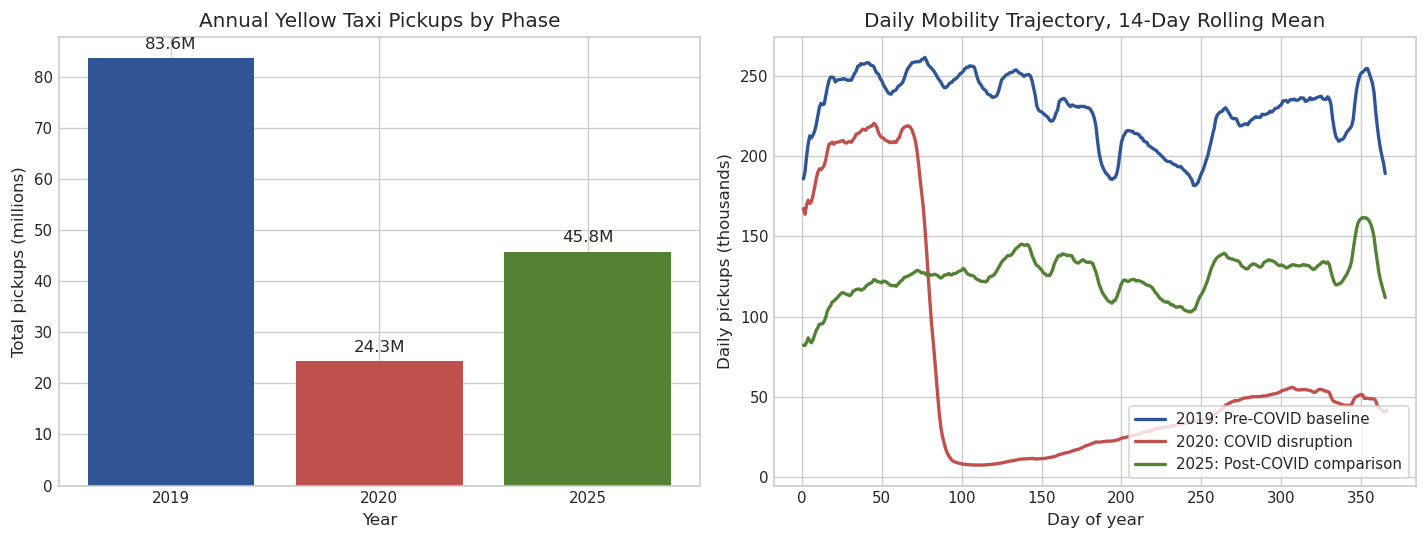

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

annual_plot = annual.sort_values("year")
axes[0].bar(
    annual_plot["year"].astype(str),
    annual_plot["total_pickups"] / 1_000_000,
    color=[YEAR_COLORS[y] for y in annual_plot["year"]],
)
axes[0].set_title("Annual Yellow Taxi Pickups by Phase")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total pickups (millions)")
for i, row in annual_plot.iterrows():
    axes[0].text(
        str(int(row["year"])),
        row["total_pickups"] / 1_000_000 + 1.2,
        f"{row['total_pickups'] / 1_000_000:.1f}M",
        ha="center",
        va="bottom",
    )

daily_for_plot = city_daily.copy()
daily_for_plot["day_of_year"] = pd.to_datetime(daily_for_plot["date"]).dt.dayofyear
for year, sub in daily_for_plot.groupby("year"):
    sub = sub.sort_values("date").copy()
    sub["rolling_14d"] = sub["daily_pickups"].rolling(14, min_periods=1).mean()
    axes[1].plot(
        sub["day_of_year"],
        sub["rolling_14d"] / 1_000,
        color=YEAR_COLORS[year],
        label=f"{year}: {PHASE_LABELS[year]}",
        linewidth=2,
    )
axes[1].set_title("Daily Mobility Trajectory, 14-Day Rolling Mean")
axes[1].set_xlabel("Day of year")
axes[1].set_ylabel("Daily pickups (thousands)")
axes[1].legend(frameon=True)

fig.tight_layout()
fig.savefig(OUT_DIR / "annual_shock_recovery.png", bbox_inches="tight")
plt.show()

## 2. Monthly and Seasonal Patterns

This section compares intra-year seasonality across the three periods. Two normalizations are useful:

- **absolute monthly totals**, which show the scale of mobility in each phase;
- **monthly index relative to each year's daily average**, which shows whether a month is high or low within its own year, independent of the large COVID-level shift.

In [6]:
month_order = list(range(1, 13))
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly = city_daily.groupby(["year", "month"]).agg(
    total_pickups=("daily_pickups", "sum"),
    mean_daily_pickups=("daily_pickups", "mean"),
    median_daily_pickups=("daily_pickups", "median"),
    days=("date", "nunique"),
).reset_index()
monthly["month_name"] = monthly["month"].map(dict(zip(month_order, month_labels)))
annual_mean = annual.set_index("year")["mean_daily_pickups"]
monthly["within_year_index"] = monthly.apply(
    lambda r: 100 * r["mean_daily_pickups"] / annual_mean.loc[r["year"]],
    axis=1,
)

monthly_wide = monthly.pivot(index="month_name", columns="year", values="mean_daily_pickups").reindex(month_labels)
monthly_index_wide = monthly.pivot(index="month_name", columns="year", values="within_year_index").reindex(month_labels)

monthly_table = monthly_wide.copy()
for col in monthly_table.columns:
    monthly_table[col] = monthly_table[col].map(fmt_int)
monthly_table

year,2019,2020,2025
month_name,,,
Jan,"242,772","204,405","107,140"
Feb,"248,777","215,050","120,928"
Mar,"251,555","95,974","126,678"
Apr,"246,357","7,816","125,822"
May,"242,435","11,081","137,308"
Jun,"229,822","18,076","134,611"
Jul,"201,424","25,442","117,534"
Aug,"193,664","32,079","106,624"
Sep,"216,522","43,834","132,999"


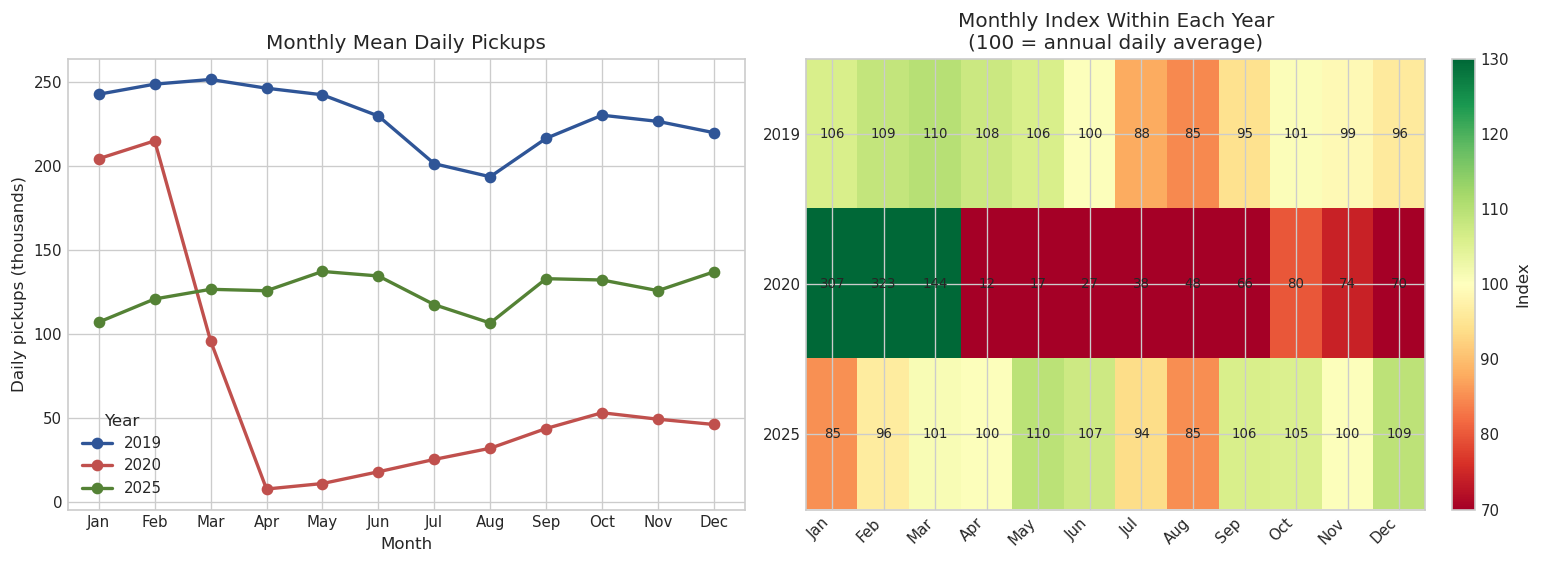

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for year, sub in monthly.groupby("year"):
    sub = sub.sort_values("month")
    axes[0].plot(
        sub["month"],
        sub["mean_daily_pickups"] / 1_000,
        marker="o",
        linewidth=2,
        color=YEAR_COLORS[year],
        label=str(year),
    )
axes[0].set_title("Monthly Mean Daily Pickups")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Daily pickups (thousands)")
axes[0].set_xticks(month_order, month_labels, rotation=0)
axes[0].legend(title="Year")

im = axes[1].imshow(monthly_index_wide.T, aspect="auto", cmap="RdYlGn", vmin=70, vmax=130)
axes[1].set_title("Monthly Index Within Each Year\n(100 = annual daily average)")
axes[1].set_xticks(range(12), month_labels, rotation=45, ha="right")
axes[1].set_yticks(range(len(monthly_index_wide.columns)), [str(y) for y in monthly_index_wide.columns])
for y_i, year in enumerate(monthly_index_wide.columns):
    for m_i, val in enumerate(monthly_index_wide[year]):
        axes[1].text(m_i, y_i, f"{val:.0f}", ha="center", va="center", fontsize=8)
cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label("Index")

fig.tight_layout()
fig.savefig(OUT_DIR / "monthly_seasonality.png", bbox_inches="tight")
plt.show()

In [8]:
seasonal = city_daily.groupby(["year", "season"]).agg(
    total_pickups=("daily_pickups", "sum"),
    mean_daily_pickups=("daily_pickups", "mean"),
    median_daily_pickups=("daily_pickups", "median"),
    days=("date", "nunique"),
).reset_index()
seasonal["within_year_index"] = seasonal.apply(
    lambda r: 100 * r["mean_daily_pickups"] / annual_mean.loc[r["year"]],
    axis=1,
)

season_order = ["winter", "spring", "summer", "fall"]
season_labels = [s.title() for s in season_order]
seasonal_display = seasonal.copy()
seasonal_display["season"] = pd.Categorical(seasonal_display["season"], season_order, ordered=True)
seasonal_display = seasonal_display.sort_values(["year", "season"])
for col in ["total_pickups", "mean_daily_pickups", "median_daily_pickups"]:
    seasonal_display[col] = seasonal_display[col].map(fmt_int)
seasonal_display["within_year_index"] = seasonal_display["within_year_index"].map(lambda x: f"{x:.1f}")
seasonal_display

,year,season,total_pickups,mean_daily_pickups,median_daily_pickups,days,within_year_index
3,2019,winter,"29,106,682","240,551","249,330",121,105.0
1,2019,spring,"14,906,206","244,364","252,699",61,106.7
2,2019,summer,"25,638,047","210,148","214,182",122,91.8
0,2019,fall,"13,937,329","228,481","237,010",61,99.8
7,2020,winter,"16,981,520","139,193","177,450",122,209.4
5,2020,spring,"578,003","9,475","8,684",61,14.3
6,2020,summer,"3,640,450","29,840","28,425",122,44.9
4,2020,fall,"3,130,596","51,321","53,566",61,77.2
11,2025,winter,"14,882,957","123,000","120,912",121,98.1
9,2025,spring,"8,031,188","131,659","133,095",61,105.0


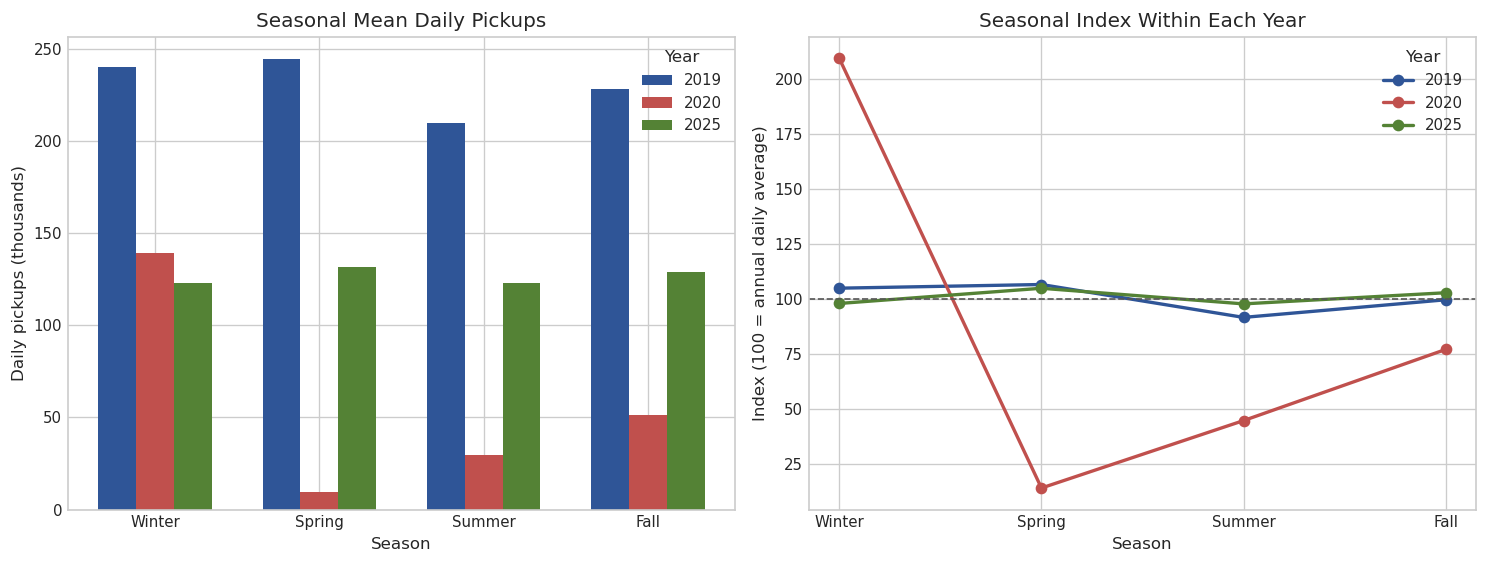

In [9]:
seasonal_plot = seasonal.copy()
seasonal_plot["season"] = pd.Categorical(seasonal_plot["season"], season_order, ordered=True)
seasonal_plot = seasonal_plot.sort_values(["season", "year"])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
width = 0.23
x = range(len(season_order))

for offset, year in zip([-width, 0, width], [2019, 2020, 2025]):
    vals = seasonal_plot[seasonal_plot["year"] == year].set_index("season").reindex(season_order)["mean_daily_pickups"]
    axes[0].bar([i + offset for i in x], vals / 1_000, width=width, color=YEAR_COLORS[year], label=str(year))
axes[0].set_title("Seasonal Mean Daily Pickups")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Daily pickups (thousands)")
axes[0].set_xticks(list(x), season_labels)
axes[0].legend(title="Year")

for year, sub in seasonal_plot.groupby("year"):
    sub = sub.set_index("season").reindex(season_order)
    axes[1].plot(
        season_labels,
        sub["within_year_index"],
        marker="o",
        linewidth=2,
        color=YEAR_COLORS[year],
        label=str(year),
    )
axes[1].axhline(100, color="#555555", linewidth=1, linestyle="--")
axes[1].set_title("Seasonal Index Within Each Year")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Index (100 = annual daily average)")
axes[1].legend(title="Year")

fig.tight_layout()
fig.savefig(OUT_DIR / "seasonal_patterns.png", bbox_inches="tight")
plt.show()

## 3. Weekday, Weekend, and Holiday Mobility Effects

The existing query notebook introduced weekday/weekend/holiday tagging. Here the comparison is extended across all three years. The table below uses citywide daily totals, so the reported values are directly interpretable as average daily pickups in each day type.

In [10]:
day_type = query('''
    WITH city_day AS (
        SELECT
            CAST(date AS DATE) AS date,
            EXTRACT(year FROM date)::INTEGER AS year,
            day_tag,
            SUM(trips_pickup) AS daily_pickups
        FROM tlc_with_day_tag
        GROUP BY 1, 2, 3
    )
    SELECT
        year,
        day_tag,
        COUNT(*) AS days,
        SUM(daily_pickups) AS total_pickups,
        AVG(daily_pickups) AS mean_daily_pickups,
        MEDIAN(daily_pickups) AS median_daily_pickups,
        MIN(daily_pickups) AS min_daily_pickups,
        MAX(daily_pickups) AS max_daily_pickups
    FROM city_day
    GROUP BY 1, 2
    ORDER BY year, CASE day_tag WHEN 'weekday' THEN 1 WHEN 'weekend' THEN 2 ELSE 3 END
''')

weekday_baseline = day_type[day_type["day_tag"] == "weekday"].set_index("year")["mean_daily_pickups"]
day_type["lift_vs_weekday_pct"] = day_type.apply(
    lambda r: (r["mean_daily_pickups"] / weekday_baseline.loc[r["year"]] - 1) * 100,
    axis=1,
)

day_type_display = day_type.copy()
for col in ["total_pickups", "mean_daily_pickups", "median_daily_pickups", "min_daily_pickups", "max_daily_pickups"]:
    day_type_display[col] = day_type_display[col].map(fmt_int)
day_type_display["lift_vs_weekday_pct"] = day_type_display["lift_vs_weekday_pct"].map(fmt_pct)
day_type_display

,year,day_tag,days,total_pickups,mean_daily_pickups,median_daily_pickups,min_daily_pickups,max_daily_pickups,lift_vs_weekday_pct
0,2019,weekday,250,"59,624,414","238,498","240,720","141,020","291,233",0.0%
1,2019,weekend,104,"22,231,004","213,760","217,048","146,645","273,574",-10.4%
2,2019,holiday,11,"1,732,846","157,531","162,512","100,806","191,563",-33.9%
3,2020,weekday,251,"17,630,561","70,241","42,601","7,358","255,673",0.0%
4,2020,weekend,104,"5,987,689","57,574","30,456","4,362","228,051",-18.0%
5,2020,holiday,11,"712,319","64,756","41,686","7,535","167,363",-7.8%
6,2025,weekday,249,"31,605,020","126,928","127,306","77,900","180,436",0.0%
7,2025,weekend,104,"13,040,894","125,393","126,744","76,963","178,455",-1.2%
8,2025,holiday,12,"1,120,712","93,393","89,720","66,809","134,437",-26.4%


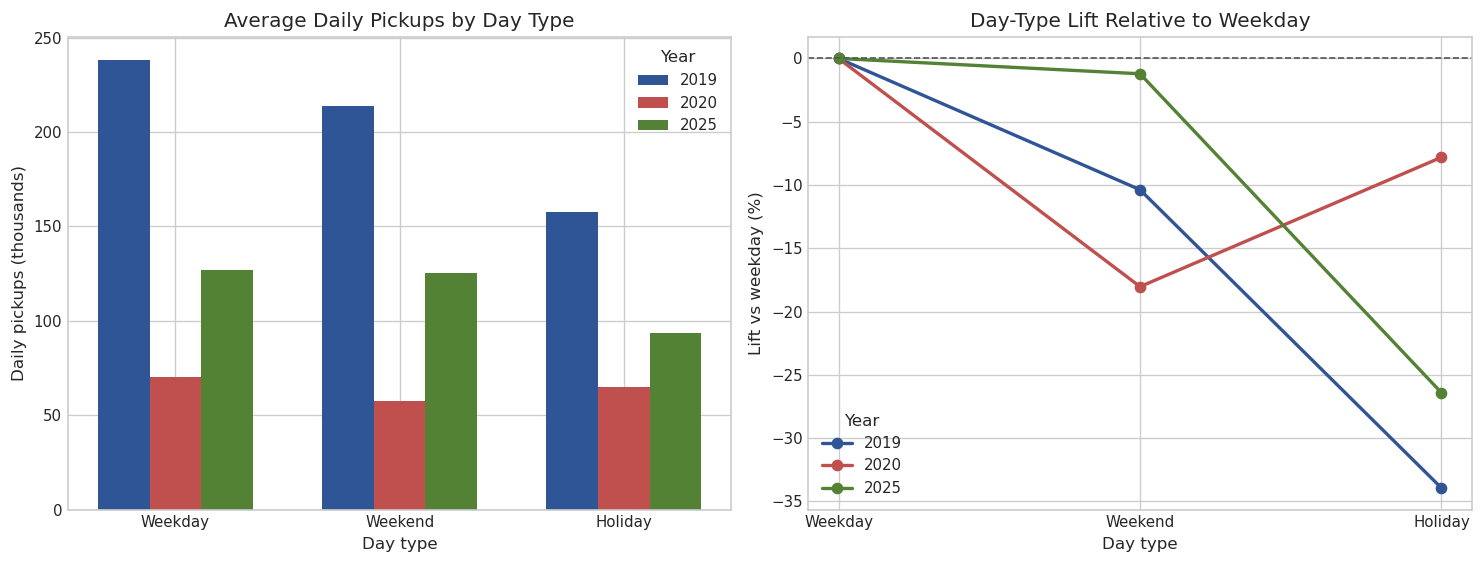

In [11]:
tag_order = ["weekday", "weekend", "holiday"]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
x = range(len(tag_order))
width = 0.23

for offset, year in zip([-width, 0, width], [2019, 2020, 2025]):
    vals = day_type[day_type["year"] == year].set_index("day_tag").reindex(tag_order)["mean_daily_pickups"]
    axes[0].bar([i + offset for i in x], vals / 1_000, width=width, color=YEAR_COLORS[year], label=str(year))
axes[0].set_title("Average Daily Pickups by Day Type")
axes[0].set_xlabel("Day type")
axes[0].set_ylabel("Daily pickups (thousands)")
axes[0].set_xticks(list(x), [t.title() for t in tag_order])
axes[0].legend(title="Year")

for year, sub in day_type.groupby("year"):
    vals = sub.set_index("day_tag").reindex(tag_order)["lift_vs_weekday_pct"]
    axes[1].plot(
        tag_order,
        vals,
        marker="o",
        linewidth=2,
        color=YEAR_COLORS[year],
        label=str(year),
    )
axes[1].axhline(0, color="#555555", linewidth=1, linestyle="--")
axes[1].set_title("Day-Type Lift Relative to Weekday")
axes[1].set_xlabel("Day type")
axes[1].set_ylabel("Lift vs weekday (%)")
axes[1].set_xticks(list(x), [t.title() for t in tag_order])
axes[1].legend(title="Year")

fig.tight_layout()
fig.savefig(OUT_DIR / "day_type_effects.png", bbox_inches="tight")
plt.show()

## Holiday Detail

Holidays are a small number of days, but they are analytically important for urban mobility because they alter commuting, tourism, shopping, and airport travel patterns. The next table ranks holidays by daily pickups within each year.

In [12]:
holiday_daily = query('''
    SELECT
        EXTRACT(year FROM date)::INTEGER AS year,
        CAST(date AS DATE) AS date,
        holiday_name,
        SUM(trips_pickup) AS daily_pickups
    FROM tlc_with_day_tag
    WHERE day_tag = 'holiday'
    GROUP BY 1, 2, 3
    ORDER BY year, daily_pickups DESC
''')
holiday_daily["rank_within_year"] = holiday_daily.groupby("year")["daily_pickups"].rank(method="first", ascending=False).astype(int)

top_holidays = holiday_daily[holiday_daily["rank_within_year"] <= 5].copy()
top_holidays_display = top_holidays[["year", "rank_within_year", "date", "holiday_name", "daily_pickups"]].copy()
top_holidays_display["daily_pickups"] = top_holidays_display["daily_pickups"].map(fmt_int)
top_holidays_display

,year,rank_within_year,date,holiday_name,daily_pickups
0,2019,1,2019-02-18,Presidents' Day,"191,563"
1,2019,2,2019-01-21,Martin Luther King Jr. Day,"187,551"
2,2019,3,2019-01-01,New Year's Day,"185,880"
3,2019,4,2019-11-11,Veterans Day,"185,346"
4,2019,5,2019-10-14,Columbus Day,"180,840"
11,2020,1,2020-01-01,New Year's Day,"167,363"
12,2020,2,2020-01-20,Martin Luther King Jr. Day,"159,949"
13,2020,3,2020-02-17,Presidents' Day,"147,284"
14,2020,4,2020-11-11,Veterans Day,"57,523"
15,2020,5,2020-12-24,Christmas Eve,"43,363"


<>:4: SyntaxWarning: invalid escape sequence '\('
<>:4: SyntaxWarning: invalid escape sequence '\('
/var/folders/gv/vjpnv0bx7r3_92xdwx3dy3z80000gn/T/ipykernel_29035/2384512577.py:4: SyntaxWarning: invalid escape sequence '\('
  labels = sub["holiday_name"].str.replace(" Day", "", regex=False).str.replace(" \(observed\)", "", regex=True)


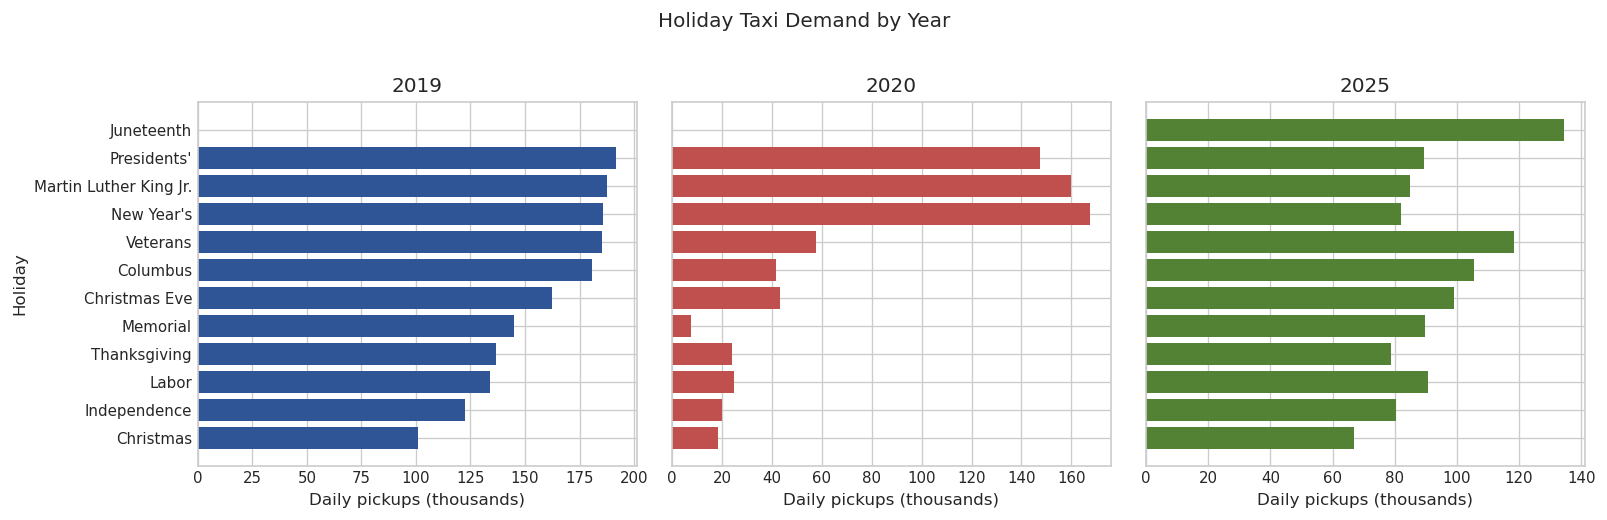

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax, year in zip(axes, [2019, 2020, 2025]):
    sub = holiday_daily[holiday_daily["year"] == year].sort_values("daily_pickups")
    labels = sub["holiday_name"].str.replace(" Day", "", regex=False).str.replace(" \(observed\)", "", regex=True)
    ax.barh(labels, sub["daily_pickups"] / 1_000, color=YEAR_COLORS[year])
    ax.set_title(str(year))
    ax.set_xlabel("Daily pickups (thousands)")
axes[0].set_ylabel("Holiday")
fig.suptitle("Holiday Taxi Demand by Year", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "holiday_detail.png", bbox_inches="tight")
plt.show()

## Combined Evidence Table for Paper Drafting

The following compact table brings together annual totals, the seasonal high/low pattern, and day-type effects. It is intended as a paper-ready descriptive evidence table.

In [14]:
seasonal_rank = seasonal.copy()
seasonal_rank["season"] = pd.Categorical(seasonal_rank["season"], season_order, ordered=True)
high_season = seasonal_rank.loc[seasonal_rank.groupby("year")["mean_daily_pickups"].idxmax(), ["year", "season", "mean_daily_pickups"]]
low_season = seasonal_rank.loc[seasonal_rank.groupby("year")["mean_daily_pickups"].idxmin(), ["year", "season", "mean_daily_pickups"]]
high_season = high_season.rename(columns={"season": "highest_season", "mean_daily_pickups": "highest_season_mean"})
low_season = low_season.rename(columns={"season": "lowest_season", "mean_daily_pickups": "lowest_season_mean"})

day_lifts = day_type.pivot(index="year", columns="day_tag", values="lift_vs_weekday_pct").reset_index()
evidence = annual[["year", "phase", "total_pickups", "mean_daily_pickups", "change_vs_2019_pct", "recovery_share_of_2019_pct"]].merge(
    high_season, on="year"
).merge(
    low_season, on="year"
).merge(
    day_lifts[["year", "weekend", "holiday"]].rename(columns={
        "weekend": "weekend_lift_vs_weekday_pct",
        "holiday": "holiday_lift_vs_weekday_pct",
    }),
    on="year",
)

evidence_display = evidence.copy()
for col in ["total_pickups", "mean_daily_pickups", "highest_season_mean", "lowest_season_mean"]:
    evidence_display[col] = evidence_display[col].map(fmt_int)
for col in ["change_vs_2019_pct", "recovery_share_of_2019_pct", "weekend_lift_vs_weekday_pct", "holiday_lift_vs_weekday_pct"]:
    evidence_display[col] = evidence_display[col].map(fmt_pct)
evidence_display

,year,phase,total_pickups,mean_daily_pickups,change_vs_2019_pct,recovery_share_of_2019_pct,highest_season,highest_season_mean,lowest_season,lowest_season_mean,weekend_lift_vs_weekday_pct,holiday_lift_vs_weekday_pct
0,2019,Pre-COVID baseline,"83,588,264","229,009",0.0%,100.0%,spring,"244,364",summer,"210,148",-10.4%,-33.9%
1,2020,COVID disruption,"24,330,569","66,477",-70.9%,29.1%,winter,"139,193",spring,"9,475",-18.0%,-7.8%
2,2025,Post-COVID comparison,"45,766,626","125,388",-45.2%,54.8%,spring,"131,659",summer,"122,764",-1.2%,-26.4%


## Interpretation Summary

Use the generated tables and figures above as descriptive evidence for the temporal mobility hypotheses:

- **COVID shock and partial recovery:** The annual summary quantifies a sharp 2020 collapse relative to 2019 and a substantial but incomplete rebound by 2025.
- **Seasonality:** Monthly and seasonal indices show whether each year follows a similar intra-year rhythm or whether the COVID year changed the seasonal structure.
- **Day-type effects:** Weekends and holidays generally differ from weekdays, but the lift/penalty varies by year, indicating that the social calendar interacted with the broader mobility regime.

Figures are also saved under `outputs/temporal_mobility/` for use in slides or paper drafts.